# CMP7005 Programming for Data Analysis  

Selected stations:
Urban: Tiantan, Wanshouxigong  
Suburban: Changping, Shunyi

## 0. Environment Setup

In [75]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from pathlib import Path
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose

In [76]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Main folder for the GitHub/reproducible version in Google Drive
BASE_DIR = Path("/content/drive/MyDrive/CMP7005_project/reproducible")

# The original raw data folder is still stored in CMP7005_project/data
DATA_DIR = BASE_DIR.parent / "data"

# New output folders for the reproducible version
FIG_DIR = BASE_DIR / "figures"
RESULT_DIR = BASE_DIR / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Base folder:", BASE_DIR)
print("Data folder:", DATA_DIR)
print("Figure folder:", FIG_DIR)
print("Result folder:", RESULT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base folder: /content/drive/MyDrive/CMP7005_project/reproducible
Data folder: /content/drive/MyDrive/CMP7005_project/data
Figure folder: /content/drive/MyDrive/CMP7005_project/reproducible/figures
Result folder: /content/drive/MyDrive/CMP7005_project/reproducible/results


## 0.1 Mount Google Drive

In [77]:
# Google Drive has already been mounted in Section 0.
print("Google Drive is mounted and ready.")

Google Drive is mounted and ready.


## 0.2 Define the Data Folder

In [78]:
print(DATA_DIR)

/content/drive/MyDrive/CMP7005_project/data


## 0.3 Create an Output Folder for Figures

In [79]:
# Output folder for figures used by this reproducible notebook
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Figure folder created:", FIG_DIR.resolve())

Figure folder created: /content/drive/MyDrive/CMP7005_project/reproducible/figures


## 0.4 Plotting Style and Helper Functions

In [80]:
sns.set_theme(style="ticks")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

STATION_ORDER = ["Changping", "Shunyi", "Tiantan", "Wanshouxigong"]

STATION_PALETTE = {
    "Changping": "#0072B2",
    "Shunyi": "#E69F00",
    "Tiantan": "#009E73",
    "Wanshouxigong": "#FF8080"
}

URBAN_STATIONS = ["Tiantan", "Wanshouxigong"]
SUBURBAN_STATIONS = ["Changping", "Shunyi"]

def apply_common_style(ax=None, y_grid=True, x_grid=False):
    if ax is None:
        ax = plt.gca()
    ax.grid(axis="y", linestyle="--", alpha=0.35) if y_grid else ax.grid(False)
    if not x_grid:
        ax.grid(axis="x", visible=False)
    return ax

def place_legend_outside(ax=None, title="Station"):
    if ax is None:
        ax = plt.gca()
    ax.legend(
        title=title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        frameon=True
    )

def save_fig(filename):
    """
    Save the current matplotlib figure to the project figures folder.
    This ensures all EDA figures can be accessed by the Streamlit GUI.
    """
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    output_path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    print("Saved:", output_path)

# Task 1: Data Selection and Handling

In [81]:
station_files = {
    "Tiantan": "PRSA_Data_Tiantan_20130301-20170228.csv",
    "Wanshouxigong": "PRSA_Data_Wanshouxigong_20130301-20170228.csv",
    "Changping": "PRSA_Data_Changping_20130301-20170228.csv",
    "Shunyi": "PRSA_Data_Shunyi_20130301-20170228.csv",
}

In [82]:
def load_station_csv(station_name, filename, data_dir):
    file_path = Path(data_dir) / filename
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)

    if "station" not in df.columns:
        df["station"] = station_name

    required_time_cols = ["year", "month", "day", "hour"]
    if all(col in df.columns for col in required_time_cols):
        df["datetime"] = pd.to_datetime(df[required_time_cols])
    else:
        raise ValueError(f"{station_name}: year/month/day/hour columns not found.")

    return df


In [83]:
frames = []
for st, fn in station_files.items():
    station_df = load_station_csv(st, fn, DATA_DIR)
    frames.append(station_df)

df_raw = pd.concat(frames, ignore_index=True)

print("Combined shape:", df_raw.shape)
display(df_raw.head())


Combined shape: (140256, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan,2013-03-01 00:00:00
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan,2013-03-01 01:00:00
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan,2013-03-01 04:00:00


# Task 2 — Exploratory Data Analysis (EDA)

## 2.1 Data Understanding

In [84]:
print("Rows and columns:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nData types and non-null counts:")
df_raw.info()

Rows and columns: (140256, 19)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        140256 non-null  int64         
 1   year      140256 non-null  int64         
 2   month     140256 non-null  int64         
 3   day       140256 non-null  int64         
 4   hour      140256 non-null  int64         
 5   PM2.5     137196 non-null  float64       
 6   PM10      138045 non-null  float64       
 7   SO2       136545 non-null  float64       
 8   NO2       136726 non-null  float64       
 9   CO        134134 non-null  float64       
 10  O3        136242 non-null  float64       
 11  TEMP      140113 non-null  float64       
 12  P

In [85]:
column_descriptions = {
    "No": "Row identifier within each station file",
    "year": "Year of observation",
    "month": "Month of observation",
    "day": "Day of observation",
    "hour": "Hour of observation",
    "PM2.5": "Fine particulate matter concentration",
    "PM10": "Particulate matter concentration",
    "SO2": "Sulfur dioxide concentration",
    "NO2": "Nitrogen dioxide concentration",
    "CO": "Carbon monoxide concentration",
    "O3": "Ozone concentration",
    "TEMP": "Temperature",
    "PRES": "Atmospheric pressure",
    "DEWP": "Dew point",
    "RAIN": "Rainfall",
    "wd": "Wind direction",
    "WSPM": "Wind speed",
    "station": "Monitoring station name",
    "datetime": "Combined timestamp"
}

desc_df = pd.DataFrame({
    "Column": df_raw.columns,
    "Description": [column_descriptions.get(col, "Description to be added if needed") for col in df_raw.columns],
    "Data Type": [str(df_raw[col].dtype) for col in df_raw.columns]
})

display(desc_df)

,Column,Description,Data Type
0,No,Row identifier within each station file,int64
1,year,Year of observation,int64
2,month,Month of observation,int64
3,day,Day of observation,int64
4,hour,Hour of observation,int64
5,PM2.5,Fine particulate matter concentration,float64
6,PM10,Particulate matter concentration,float64
7,SO2,Sulfur dioxide concentration,float64
8,NO2,Nitrogen dioxide concentration,float64
9,CO,Carbon monoxide concentration,float64


In [86]:
display(df_raw.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
No,140256.0,NaN,NaN,NaN,17532.5,1.0,8766.75,17532.5,26298.25,35064.0,10122.141
year,140256.0,NaN,NaN,NaN,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177201
month,140256.0,NaN,NaN,NaN,6.52293,1.0,4.0,7.0,10.0,12.0,3.448715
day,140256.0,NaN,NaN,NaN,15.729637,1.0,8.0,16.0,23.0,31.0,8.800123
hour,140256.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922211
PM2.5,137196.0,NaN,NaN,NaN,79.450146,2.0,20.0,55.0,110.0,999.0,80.435402
PM10,138045.0,NaN,NaN,NaN,103.000643,2.0,36.0,81.0,142.0,999.0,90.370174
SO2,136545.0,NaN,NaN,NaN,15.020504,0.2856,2.0,6.0,18.0,411.0,21.276987
NO2,136726.0,NaN,NaN,NaN,49.216515,1.8477,24.0,42.0,68.0,258.0,32.575737
CO,134134.0,NaN,NaN,NaN,1252.668056,100.0,500.0,900.0,1600.0,10000.0,1167.476272


In [87]:
missing_counts = df_raw.isnull().sum().sort_values(ascending=False)
missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent.round(2)
})

print("Number of selected stations:", df_raw["station"].nunique())
print("Stations used:", sorted(df_raw["station"].unique()))
print("Date range:", df_raw["datetime"].min(), "to", df_raw["datetime"].max())

print("\nTop missing columns:")
display(missing_df[missing_df["Missing Count"] > 0].head(10))

print("\nDuplicate rows:", df_raw.duplicated().sum())

Number of selected stations: 4
Stations used: ['Changping', 'Shunyi', 'Tiantan', 'Wanshouxigong']
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00

Top missing columns:


,Missing Count,Missing %
CO,6122,4.36
O3,4014,2.86
SO2,3711,2.65
NO2,3530,2.52
PM2.5,3060,2.18
PM10,2211,1.58
wd,780,0.56
DEWP,146,0.10
TEMP,143,0.10
RAIN,141,0.10



Duplicate rows: 0


## 2.2 Data Pre-processing

In [88]:
df = df_raw.copy()
df = df.drop_duplicates().sort_values(["station", "datetime"]).reset_index(drop=True)

pollution_weather_cols = [col for col in [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
] if col in df.columns]

for col in pollution_weather_cols:
    df[col] = df.groupby("station")[col].transform(lambda s: s.fillna(s.median()))

if "wd" in df.columns:
    def fill_mode(series):
        mode_vals = series.mode(dropna=True)
        if len(mode_vals) > 0:
            return series.fillna(mode_vals.iloc[0])
        return series.fillna("Unknown")
    df["wd"] = df.groupby("station")["wd"].transform(fill_mode)

df["year_num"] = df["datetime"].dt.year
df["month_num"] = df["datetime"].dt.month
df["day_num"] = df["datetime"].dt.day
df["hour_num"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.day_name()
df["is_weekend"] = df["datetime"].dt.dayofweek >= 5
df["station_type"] = np.where(df["station"].isin(URBAN_STATIONS), "Urban", "Suburban")

def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month_num"].apply(month_to_season)

def pm25_category(value):
    if pd.isna(value):
        return np.nan
    elif value <= 35:
        return "Good"
    elif value <= 75:
        return "Moderate"
    elif value <= 115:
        return "Unhealthy for Sensitive Groups"
    elif value <= 150:
        return "Unhealthy"
    elif value <= 250:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df["PM25_Level"] = df["PM2.5"].apply(pm25_category)

print("Cleaned shape:", df.shape)
print("\nRemaining missing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Cleaned shape: (140256, 28)

Remaining missing values:


,0


In [89]:
display(df.head())
display(df.dtypes)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,datetime,year_num,month_num,day_num,hour_num,dayofweek,is_weekend,station_type,season,PM25_Level
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,...,2013-03-01 00:00:00,2013,3,1,0,Friday,False,Suburban,Spring,Good
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,...,2013-03-01 01:00:00,2013,3,1,1,Friday,False,Suburban,Spring,Good
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,...,2013-03-01 02:00:00,2013,3,1,2,Friday,False,Suburban,Spring,Good
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,...,2013-03-01 03:00:00,2013,3,1,3,Friday,False,Suburban,Spring,Good
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,...,2013-03-01 04:00:00,2013,3,1,4,Friday,False,Suburban,Spring,Good


,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [90]:
pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
pollutant_cols = [c for c in pollutant_cols if c in df.columns]

weather_cols = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
weather_cols = [c for c in weather_cols if c in df.columns]

analysis_cols = pollutant_cols + weather_cols

print("Pollutants:", pollutant_cols)
print("Weather variables:", weather_cols)

Pollutants: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
Weather variables: ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


In [91]:
output_path = RESULT_DIR / "combined_cleaned_air_quality.csv"
df.to_csv(output_path, index=False)
print("Saved cleaned dataset to:", output_path)

Saved cleaned dataset to: /content/drive/MyDrive/CMP7005_project/reproducible/results/combined_cleaned_air_quality.csv


## 2.3 Computational Analysis and Visualisation

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/01_pollutant_distributions.png


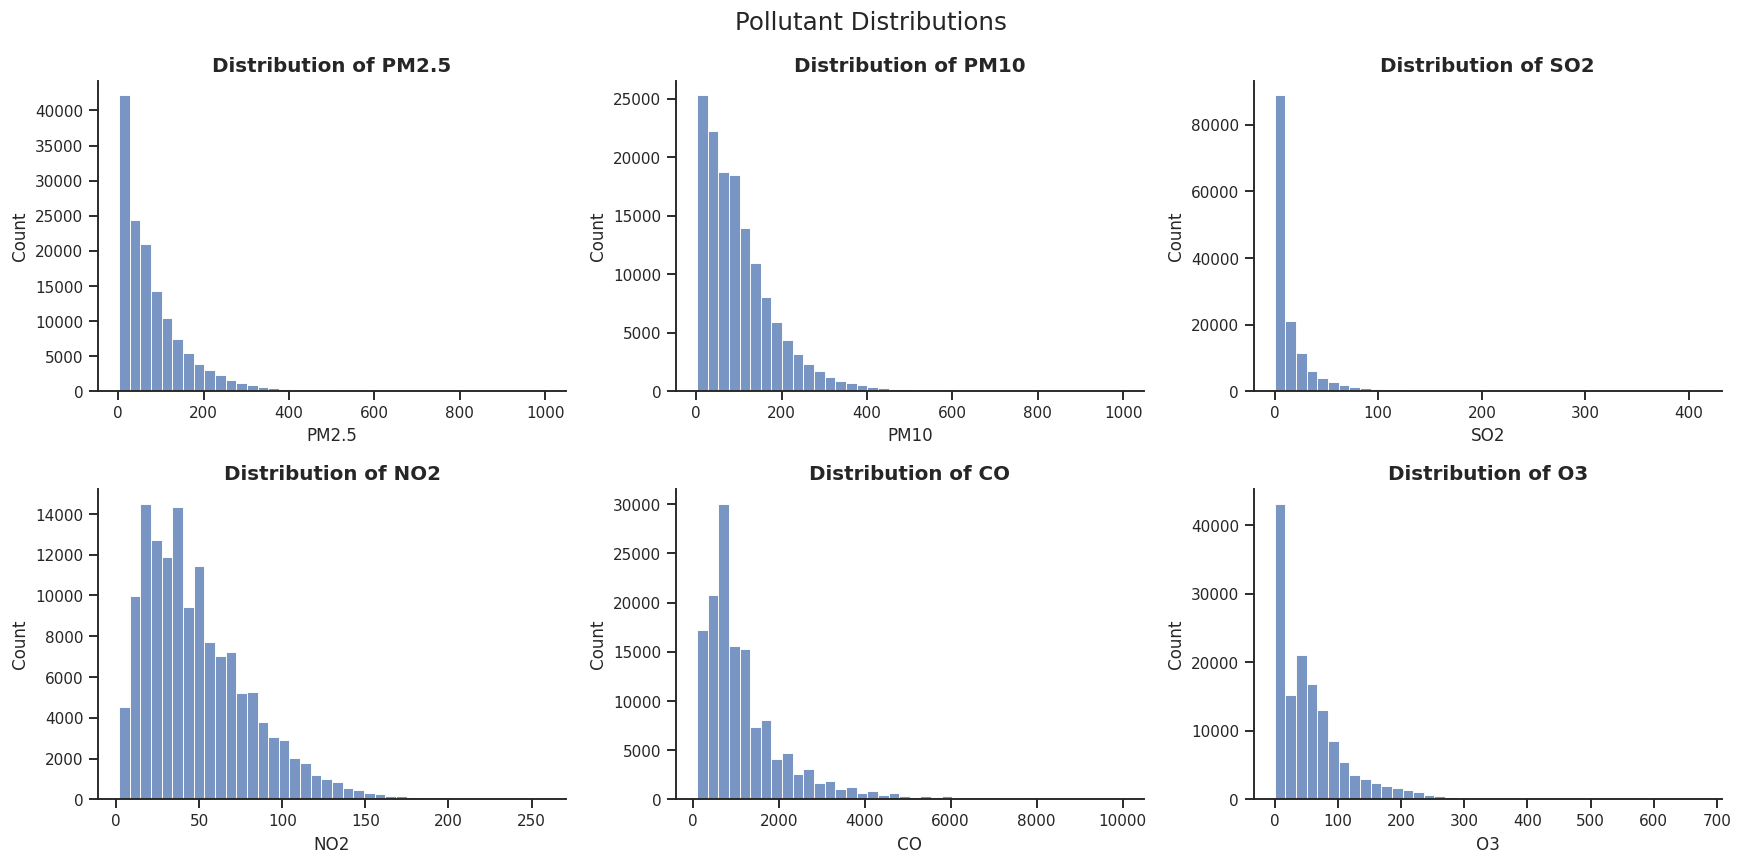

In [92]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    sns.histplot(df[col].dropna(), bins=40, color="#4C72B0", edgecolor=None, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(pollutant_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Pollutant Distributions", fontsize=16)
plt.tight_layout()
save_fig("01_pollutant_distributions.png")
plt.show()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/02_meteorological_variable_distributions.png


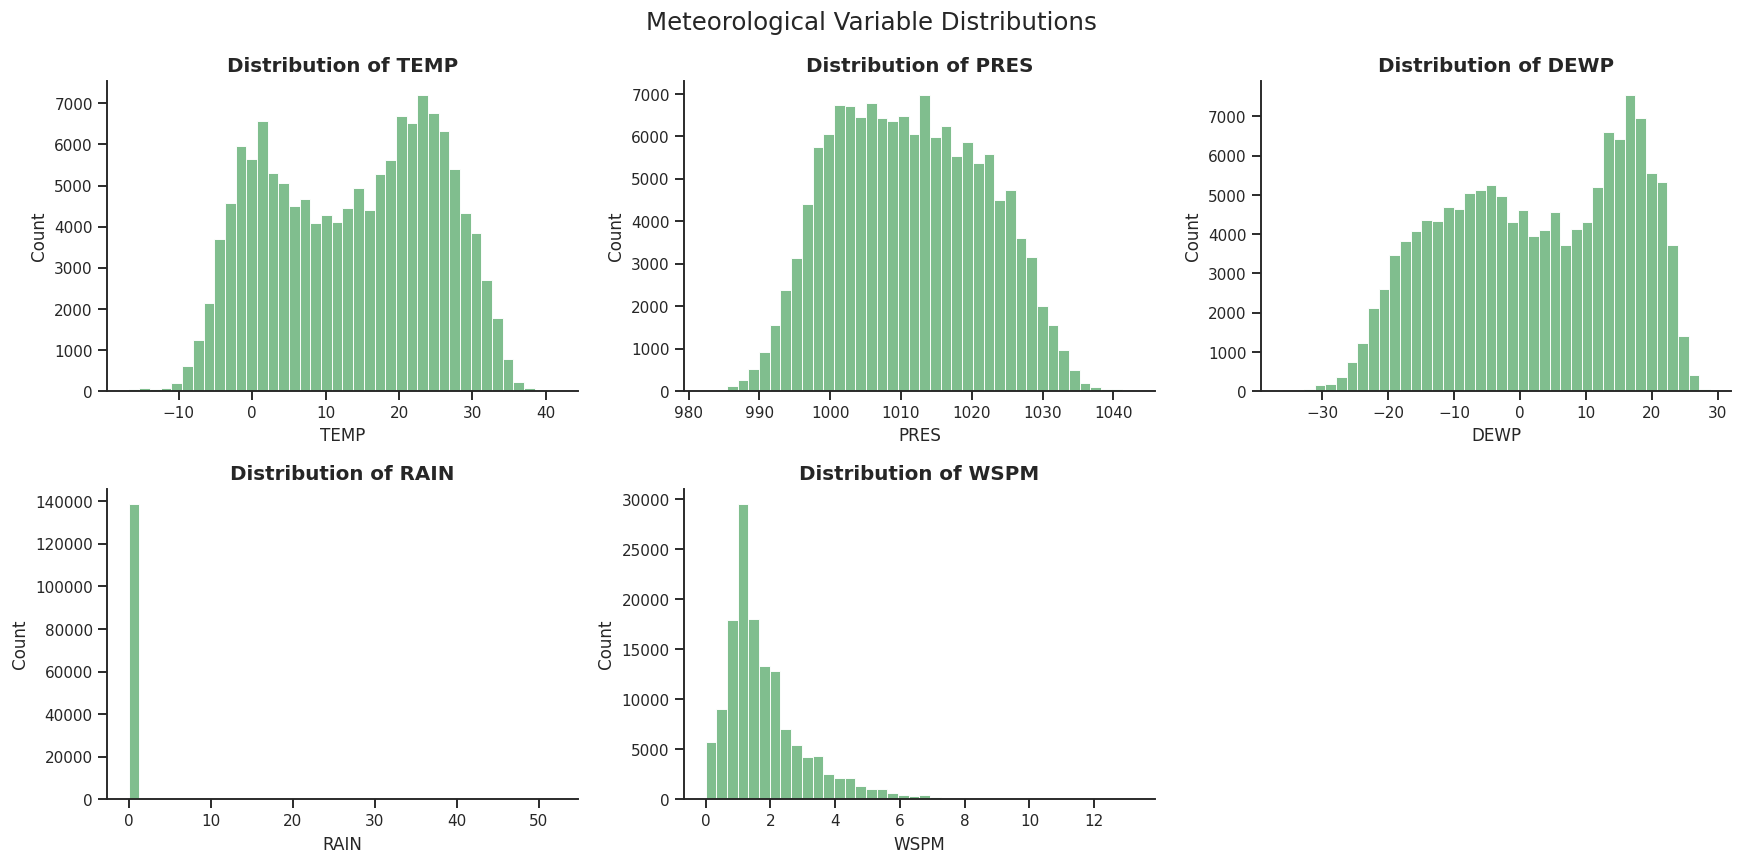

In [93]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    sns.histplot(df[col].dropna(), bins=40, color="#55A868", edgecolor=None, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(weather_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Meteorological Variable Distributions", fontsize=16)
plt.tight_layout()
save_fig("02_meteorological_variable_distributions.png")
plt.show()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/03_pm25_station_median_iqr.png


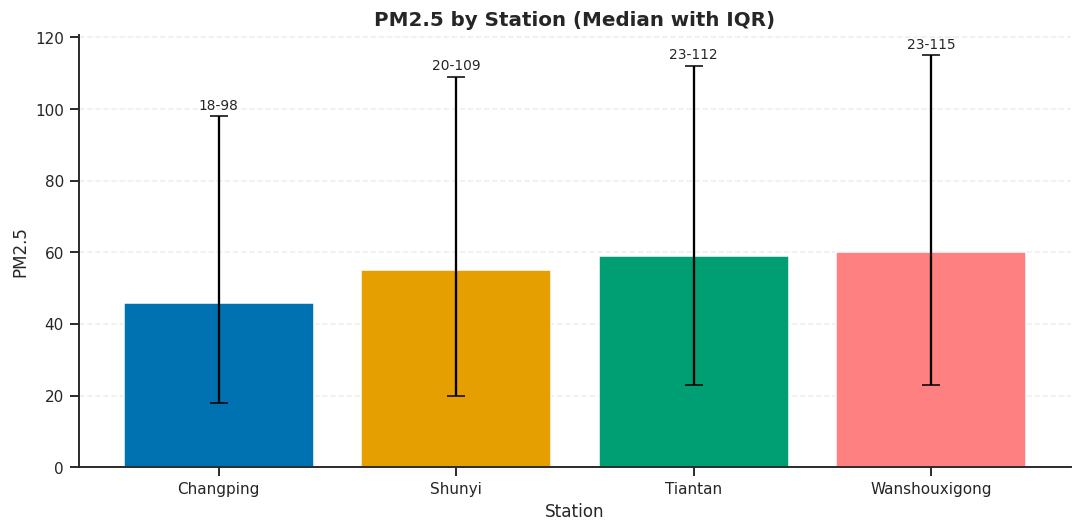

In [94]:
summary = (
    df.groupby("station")["PM2.5"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reindex(STATION_ORDER)
    .reset_index()
)

med = summary["median"]
yerr = np.vstack([med - summary["q25"], summary["q75"] - med])

plt.figure(figsize=(10, 5))

plt.bar(
    summary["station"],
    med,
    color=[STATION_PALETTE[s] for s in summary["station"]]
)

plt.errorbar(
    summary["station"],
    med,
    yerr=yerr,
    fmt="none",
    capsize=6,
    color="black"
)

for i, station in enumerate(summary["station"]):
    plt.text(
        i,
        summary["q75"][i] + 2,
        f"{int(summary['q25'][i])}-{int(summary['q75'][i])}",
        ha='center',
        fontsize=9
    )

plt.title("PM2.5 by Station (Median with IQR)")
plt.xlabel("Station")
plt.ylabel("PM2.5")

apply_common_style()
save_fig("03_pm25_station_median_iqr.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/04_pm25_distribution_by_station_kde.png


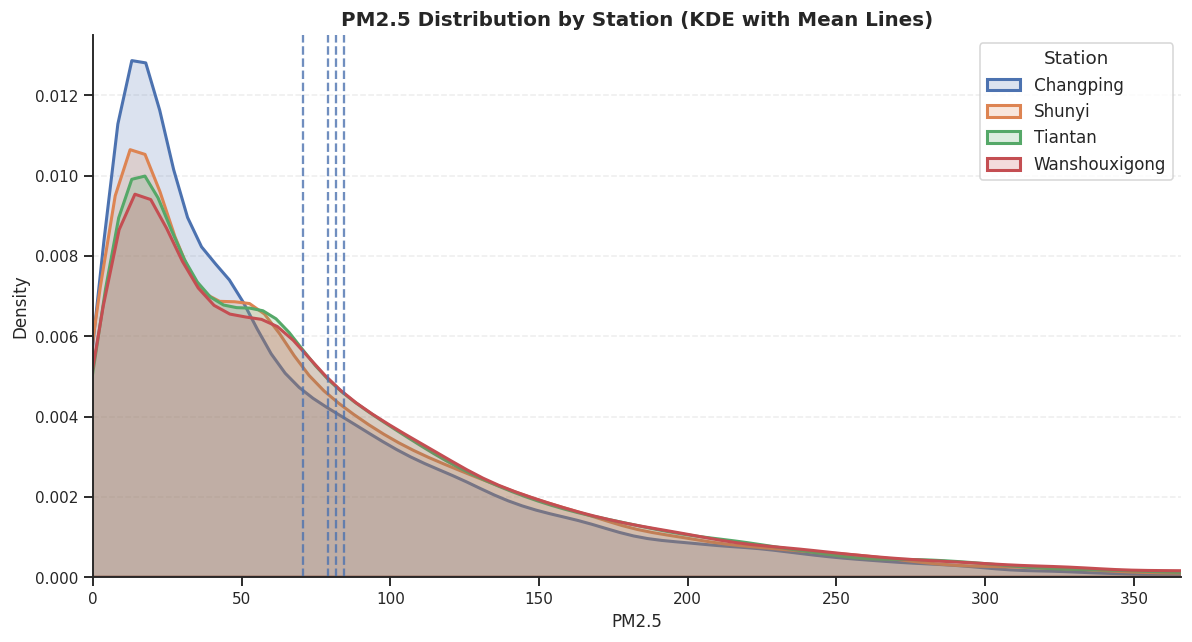

In [95]:
plt.figure(figsize=(11, 6))

x_max = df["PM2.5"].quantile(0.99)

for station in STATION_ORDER:
    station_data = df[df["station"] == station]["PM2.5"].dropna()

    sns.kdeplot(
        station_data,
        fill=True,
        alpha=0.20,
        linewidth=2,
        label=station
    )

    mean_val = station_data.mean()
    plt.axvline(
        mean_val,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8
    )

plt.xlim(0, x_max)
plt.title("PM2.5 Distribution by Station (KDE with Mean Lines)")
plt.xlabel("PM2.5")
plt.ylabel("Density")
plt.legend(title="Station")
apply_common_style()
save_fig("04_pm25_distribution_by_station_kde.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/05_mean_pm25_urban_suburban.png


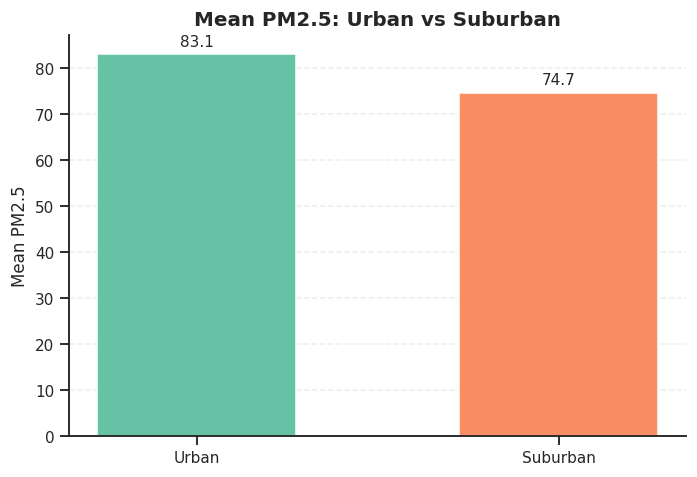

In [96]:
urban_suburban_pm25 = (
    df.groupby("station_type")["PM2.5"]
    .mean()
    .reindex(["Urban", "Suburban"])
)

plt.figure(figsize=(6.5, 4.5))

bars = plt.bar(
    urban_suburban_pm25.index,
    urban_suburban_pm25.values,
    color=["#66C2A5", "#FC8D62"],
    width=0.55
)

plt.title("Mean PM2.5: Urban vs Suburban")
plt.ylabel("Mean PM2.5")
plt.xlabel("")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

apply_common_style()
save_fig("05_mean_pm25_urban_suburban.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/06_pm25_vs_temp_density_trend.png


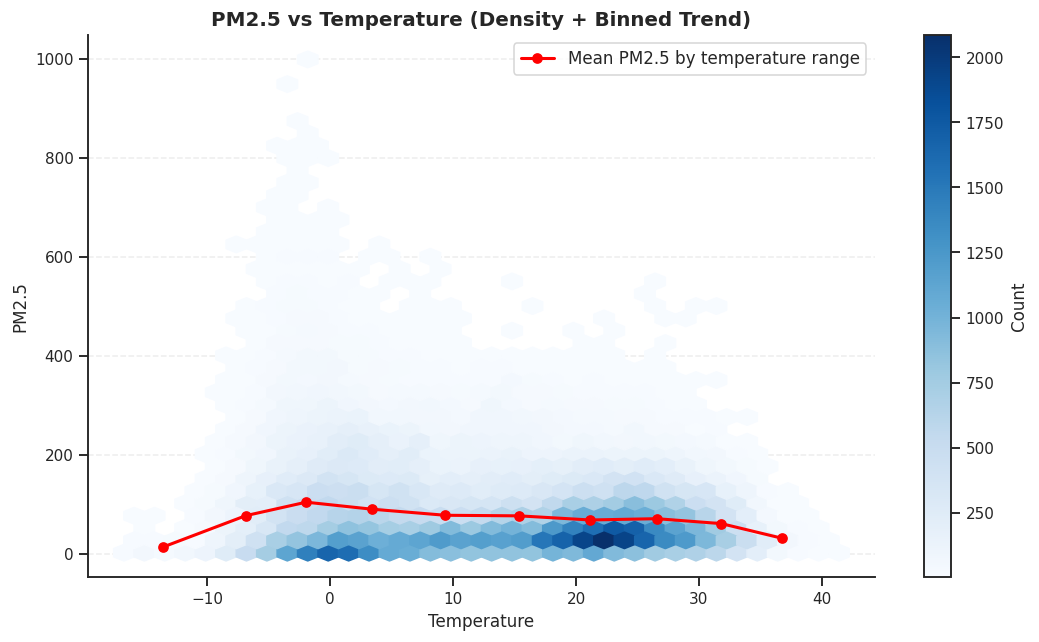

In [97]:
temp_df = df[["TEMP", "PM2.5"]].dropna().copy()

plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    temp_df["TEMP"],
    temp_df["PM2.5"],
    gridsize=35,
    cmap="Blues",
    mincnt=1
)
cb = plt.colorbar(hb)
cb.set_label("Count")


temp_df["temp_bin"] = pd.cut(temp_df["TEMP"], bins=10)
trend = (
    temp_df.groupby("temp_bin", observed=False)
    .agg(
        temp_mid=("TEMP", "mean"),
        pm25_mean=("PM2.5", "mean")
    )
    .dropna()
    .sort_values("temp_mid")
)

plt.plot(
    trend["temp_mid"],
    trend["pm25_mean"],
    color="red",
    marker="o",
    linewidth=2,
    label="Mean PM2.5 by temperature range"
)

plt.title("PM2.5 vs Temperature (Density + Binned Trend)")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.legend()

apply_common_style()
save_fig("06_pm25_vs_temp_density_trend.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/07_no2_vs_o3_density_trend.png


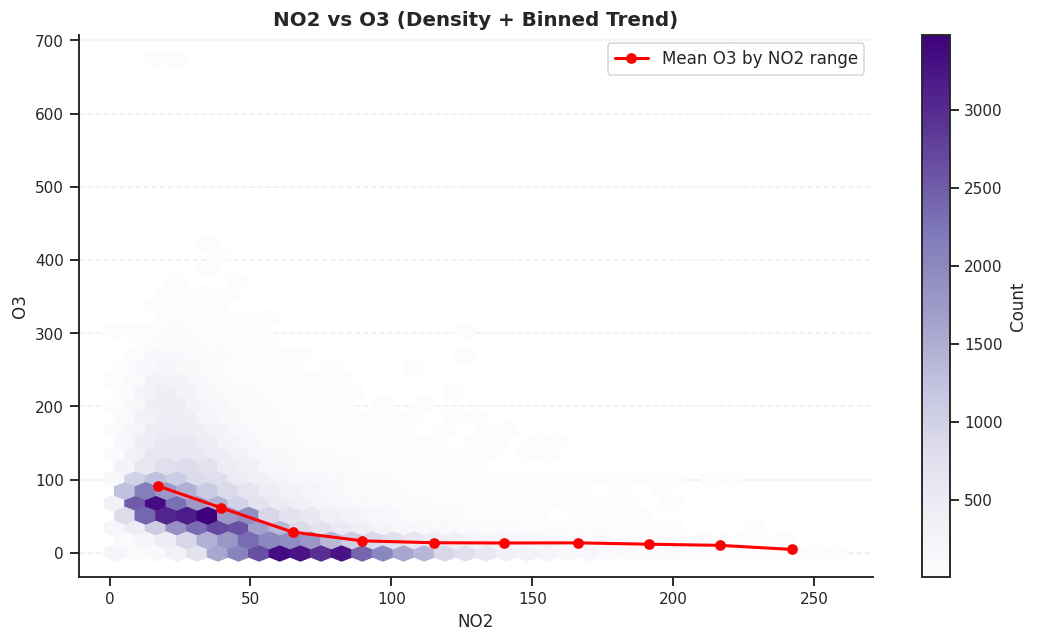

Correlation between NO2 and O3: -0.483


In [98]:
no2_o3_df = df[["NO2", "O3"]].dropna().copy()

plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    no2_o3_df["NO2"],
    no2_o3_df["O3"],
    gridsize=35,
    cmap="Purples",
    mincnt=1
)
cb = plt.colorbar(hb)
cb.set_label("Count")

no2_o3_df["no2_bin"] = pd.cut(no2_o3_df["NO2"], bins=10)

trend = (
    no2_o3_df.groupby("no2_bin", observed=False)
    .agg(
        no2_mid=("NO2", "mean"),
        o3_mean=("O3", "mean")
    )
    .dropna()
    .sort_values("no2_mid")
)

plt.plot(
    trend["no2_mid"],
    trend["o3_mean"],
    color="red",
    marker="o",
    linewidth=2,
    label="Mean O3 by NO2 range"
)

plt.title("NO2 vs O3 (Density + Binned Trend)")
plt.xlabel("NO2")
plt.ylabel("O3")
plt.legend()

apply_common_style()
save_fig("07_no2_vs_o3_density_trend.png")
plt.show()
plt.close()

print("Correlation between NO2 and O3:", round(df[["NO2", "O3"]].corr().iloc[0, 1], 3))

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/08_correlation_heatmap.png


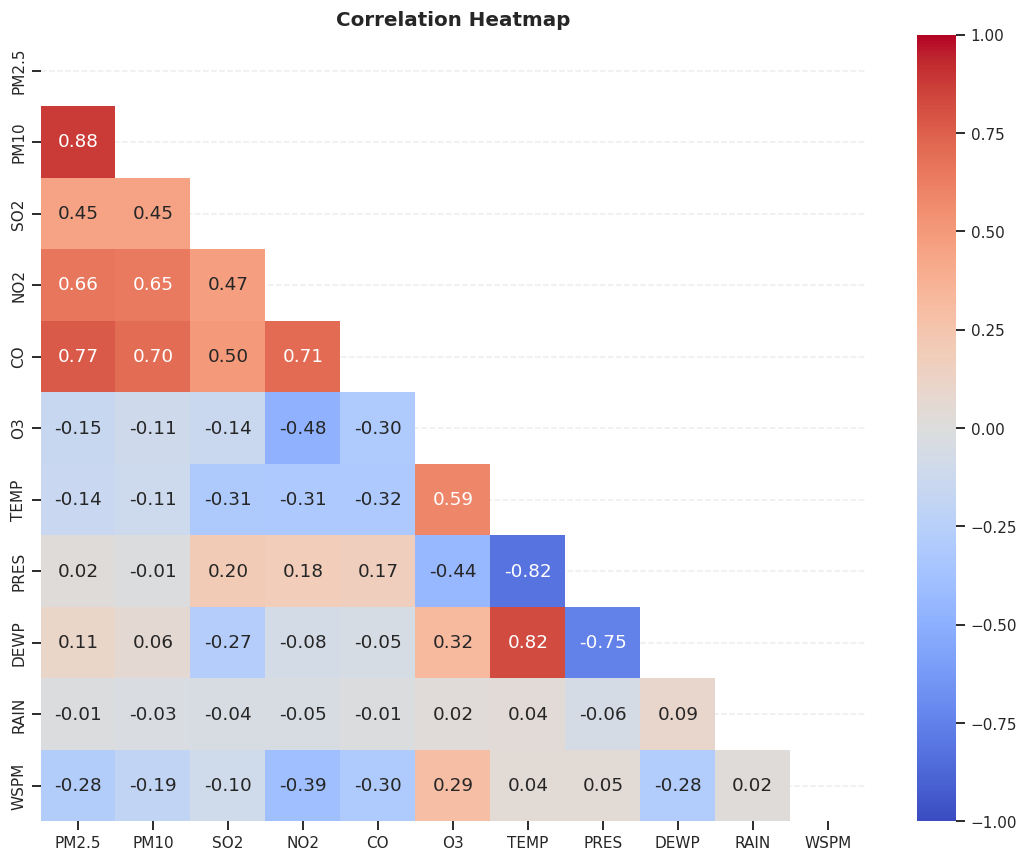

In [99]:
corr = df[analysis_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
apply_common_style()
save_fig("08_correlation_heatmap.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/09_corr_with_pm25.png


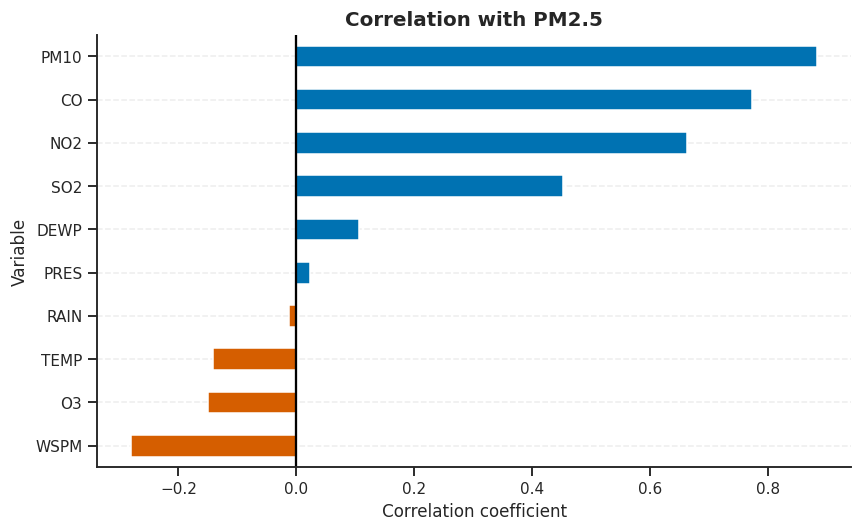

In [100]:
pm25_corr = corr["PM2.5"].drop("PM2.5").sort_values()

plt.figure(figsize=(8, 5))
colors = ["#D55E00" if v < 0 else "#0072B2" for v in pm25_corr]
pm25_corr.plot(kind="barh", color=colors)

plt.axvline(0, color="black")
plt.title("Correlation with PM2.5")
plt.xlabel("Correlation coefficient")
plt.ylabel("Variable")

apply_common_style()
save_fig("09_corr_with_pm25.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/10_pm25_seasonal_pattern_by_month.png


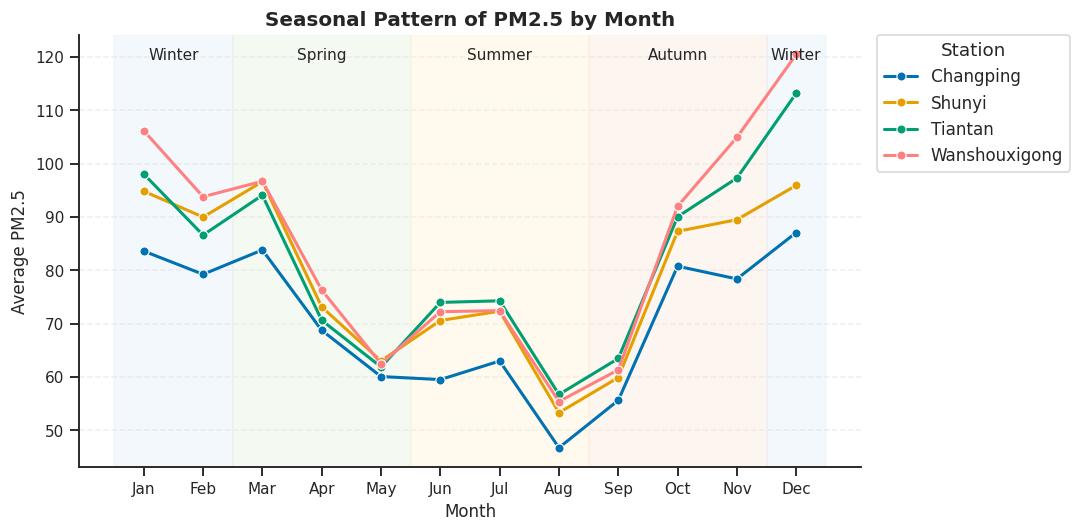

In [101]:
monthly_season = (
    df.groupby([df["datetime"].dt.month, "station"])["PM2.5"]
    .mean()
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=monthly_season,
    x="datetime",
    y="PM2.5",
    hue="station",
    hue_order=STATION_ORDER,
    palette=STATION_PALETTE,
    linewidth=2,
    marker="o"
)

ax.axvspan(0.5, 2.5, color="#DDEBF7", alpha=0.35)
ax.axvspan(2.5, 5.5, color="#E2F0D9", alpha=0.35)
ax.axvspan(5.5, 8.5, color="#FFF2CC", alpha=0.35)
ax.axvspan(8.5, 11.5, color="#FCE4D6", alpha=0.35)
ax.axvspan(11.5, 12.5, color="#DDEBF7", alpha=0.35)

ax.text(1.5, ax.get_ylim()[1] * 0.98, "Winter", ha="center", va="top", fontsize=10)
ax.text(4.0, ax.get_ylim()[1] * 0.98, "Spring", ha="center", va="top", fontsize=10)
ax.text(7.0, ax.get_ylim()[1] * 0.98, "Summer", ha="center", va="top", fontsize=10)
ax.text(10.0, ax.get_ylim()[1] * 0.98, "Autumn", ha="center", va="top", fontsize=10)
ax.text(12.0, ax.get_ylim()[1] * 0.98, "Winter", ha="center", va="top", fontsize=10)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)

plt.title("Seasonal Pattern of PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

apply_common_style()
place_legend_outside()
save_fig("10_pm25_seasonal_pattern_by_month.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/11_monthly_pm25_urban_suburban_improved.png


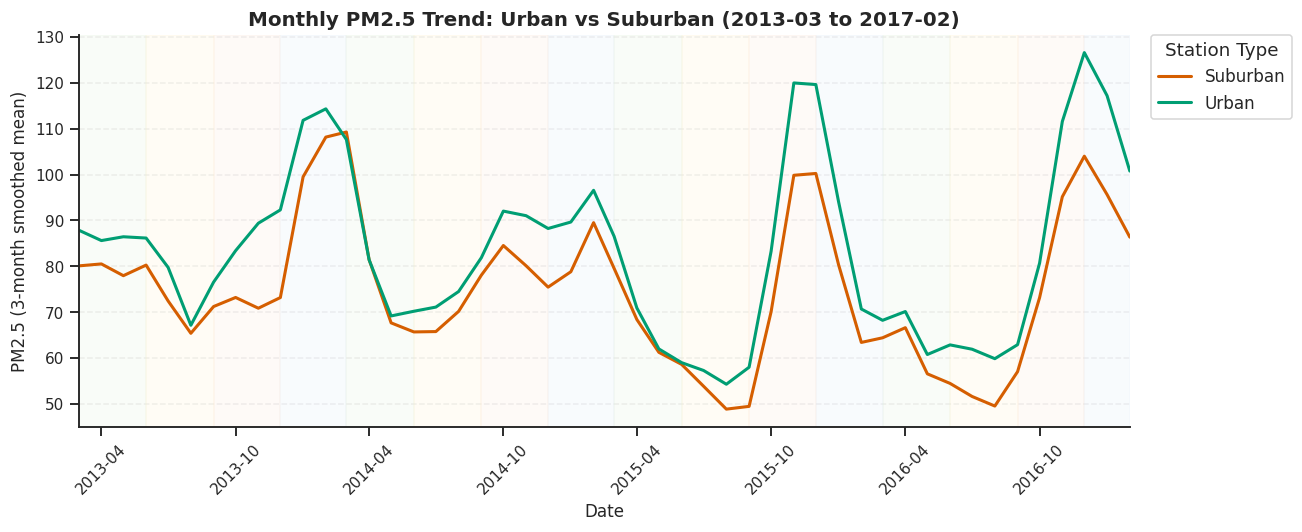

In [102]:
monthly_type = (
    df.groupby([df["datetime"].dt.to_period("M"), "station_type"])["PM2.5"]
    .mean()
    .reset_index()
)

monthly_type["datetime"] = monthly_type["datetime"].dt.to_timestamp()

monthly_type["PM2.5_smooth"] = monthly_type.groupby("station_type")["PM2.5"].transform(
    lambda x: x.rolling(window=3, center=True, min_periods=1).mean()
)

plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=monthly_type,
    x="datetime",
    y="PM2.5_smooth",
    hue="station_type",
    hue_order=["Suburban", "Urban"],
    palette={"Suburban": "#D55E00", "Urban": "#009E73"},
    linewidth=2
)

start_date = monthly_type["datetime"].min()
end_date = monthly_type["datetime"].max()
ax.set_xlim(start_date, end_date)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

season_colors = {
    "Winter": "#DDEBF7",
    "Spring": "#E2F0D9",
    "Summer": "#FFF2CC",
    "Autumn": "#FCE4D6"
}

for year in range(start_date.year, end_date.year + 1):
    winter_start = pd.to_datetime(f"{year}-12-01")
    winter_end = pd.to_datetime(f"{year + 1}-03-01")
    if winter_end >= start_date and winter_start <= end_date:
        ax.axvspan(
            max(winter_start, start_date),
            min(winter_end, end_date),
            color=season_colors["Winter"],
            alpha=0.18
        )

    spring_start = pd.to_datetime(f"{year}-03-01")
    spring_end = pd.to_datetime(f"{year}-06-01")
    if spring_end >= start_date and spring_start <= end_date:
        ax.axvspan(
            max(spring_start, start_date),
            min(spring_end, end_date),
            color=season_colors["Spring"],
            alpha=0.18
        )

    summer_start = pd.to_datetime(f"{year}-06-01")
    summer_end = pd.to_datetime(f"{year}-09-01")
    if summer_end >= start_date and summer_start <= end_date:
        ax.axvspan(
            max(summer_start, start_date),
            min(summer_end, end_date),
            color=season_colors["Summer"],
            alpha=0.18
        )

    autumn_start = pd.to_datetime(f"{year}-09-01")
    autumn_end = pd.to_datetime(f"{year}-12-01")
    if autumn_end >= start_date and autumn_start <= end_date:
        ax.axvspan(
            max(autumn_start, start_date),
            min(autumn_end, end_date),
            color=season_colors["Autumn"],
            alpha=0.18
        )

plt.title("Monthly PM2.5 Trend: Urban vs Suburban (2013-03 to 2017-02)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (3-month smoothed mean)")

apply_common_style()
place_legend_outside(title="Station Type")
save_fig("11_monthly_pm25_urban_suburban_improved.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/12_seasonal_pm25_urban_suburban_simple.png


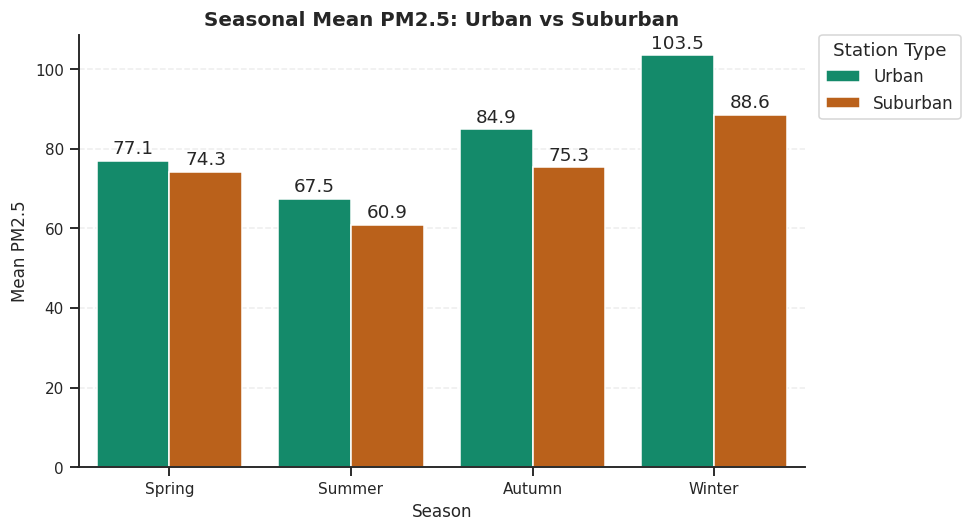

In [103]:
season_order = ["Spring", "Summer", "Autumn", "Winter"]

seasonal_type = (
    df.groupby(["season", "station_type"])["PM2.5"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=seasonal_type,
    x="season",
    y="PM2.5",
    hue="station_type",
    order=season_order,
    hue_order=["Urban", "Suburban"],
    palette={"Urban": "#009E73", "Suburban": "#D55E00"}
)

plt.title("Seasonal Mean PM2.5: Urban vs Suburban")
plt.xlabel("Season")
plt.ylabel("Mean PM2.5")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2)

apply_common_style()
place_legend_outside(title="Station Type")
save_fig("12_seasonal_pm25_urban_suburban_simple.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/13_diurnal_pm25_pattern_day_night_simplified.png


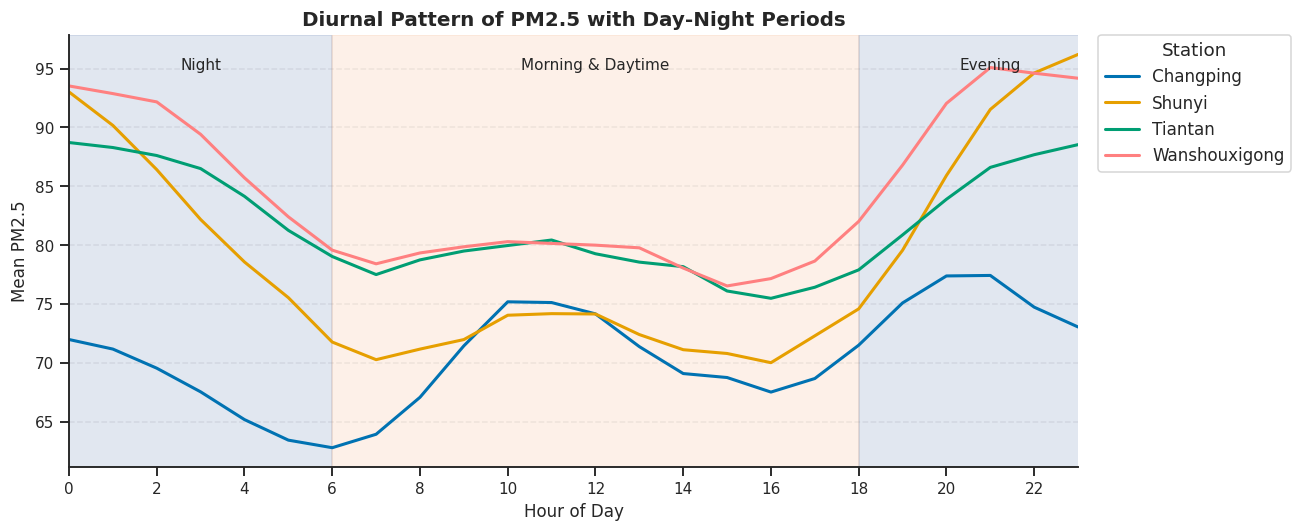

In [104]:
hourly = df.groupby(["hour_num", "station"])["PM2.5"].mean().reset_index()

plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=hourly,
    x="hour_num",
    y="PM2.5",
    hue="station",
    hue_order=STATION_ORDER,
    palette=STATION_PALETTE,
    linewidth=2,
    errorbar=("ci", 95)
)

ax.axvspan(0, 6, color="#2F5597", alpha=0.14)
ax.axvspan(6, 18, color="#F4B183", alpha=0.18)
ax.axvspan(18, 24, color="#2F5597", alpha=0.14)

y_top = ax.get_ylim()[1]

ax.text(3, y_top * 0.98, "Night", ha="center", va="top", fontsize=10)
ax.text(12, y_top * 0.98, "Morning & Daytime", ha="center", va="top", fontsize=10)
ax.text(21, y_top * 0.98, "Evening", ha="center", va="top", fontsize=10)

ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)

plt.title("Diurnal Pattern of PM2.5 with Day-Night Periods")
plt.xlabel("Hour of Day")
plt.ylabel("Mean PM2.5")

apply_common_style()
place_legend_outside(title="Station")
save_fig("13_diurnal_pm25_pattern_day_night_simplified.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/14_pm25_air_quality_levels_pie.png


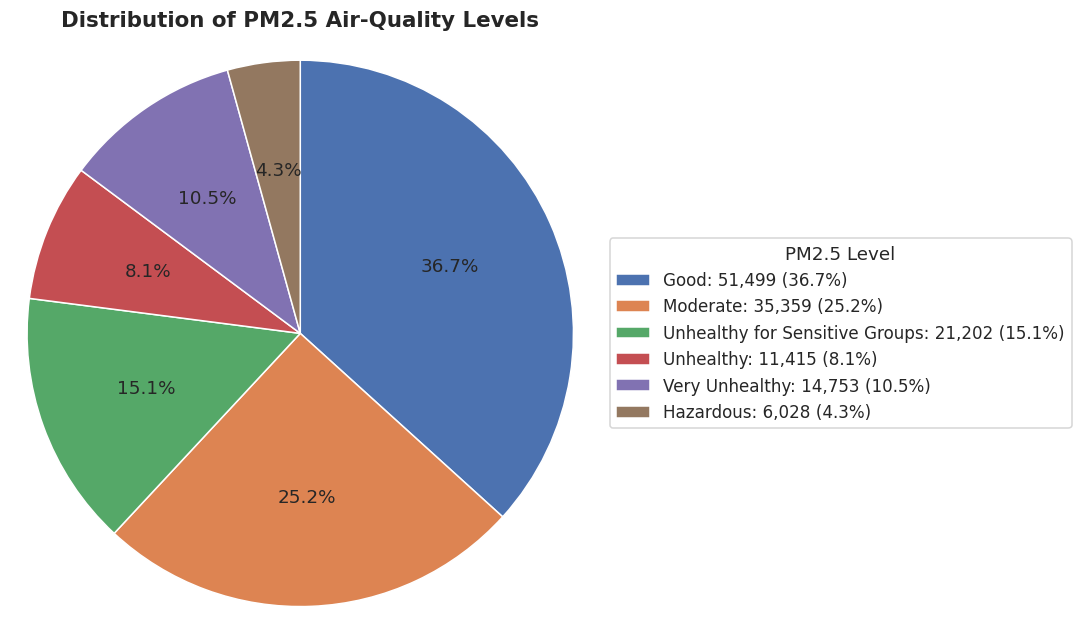

In [105]:
pm25_level_order = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous"
]

pm25_level_counts = (
    df["PM25_Level"]
    .value_counts()
    .reindex(pm25_level_order)
)

pm25_level_percent = pm25_level_counts / pm25_level_counts.sum() * 100

legend_labels = [
    f"{level}: {count:,} ({percent:.1f}%)"
    for level, count, percent in zip(
        pm25_level_counts.index,
        pm25_level_counts.values,
        pm25_level_percent.values
    )
]

colors = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B2",
    "#937860"
]

fig, ax = plt.subplots(figsize=(10, 6))

wedges, texts, autotexts = ax.pie(
    pm25_level_counts,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

ax.set_title("Distribution of PM2.5 Air-Quality Levels", fontsize=14, weight="bold")

ax.axis("equal")

ax.legend(
    wedges,
    legend_labels,
    title="PM2.5 Level",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()
save_fig("14_pm25_air_quality_levels_pie.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/15_average_pm25_weekday_weekend_pie.png


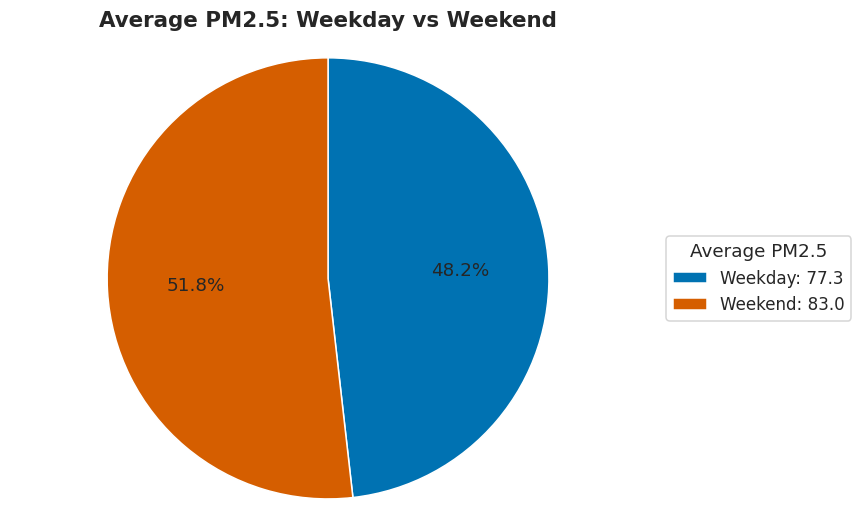

In [106]:
weekday_weekend = (
    df.groupby("is_weekend")["PM2.5"]
    .mean()
    .rename(index={False: "Weekday", True: "Weekend"})
)

labels = [
    f"{label}: {value:.1f}"
    for label, value in weekday_weekend.items()
]

colors = ["#0072B2", "#D55E00"]

fig, ax = plt.subplots(figsize=(8, 5))

wedges, texts, autotexts = ax.pie(
    weekday_weekend.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

ax.set_title("Average PM2.5: Weekday vs Weekend", fontsize=14, weight="bold")
ax.axis("equal")

ax.legend(
    wedges,
    labels,
    title="Average PM2.5",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()
save_fig("15_average_pm25_weekday_weekend_pie.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/16_wind_direction_frequency_polar_with_regions_spacious.png


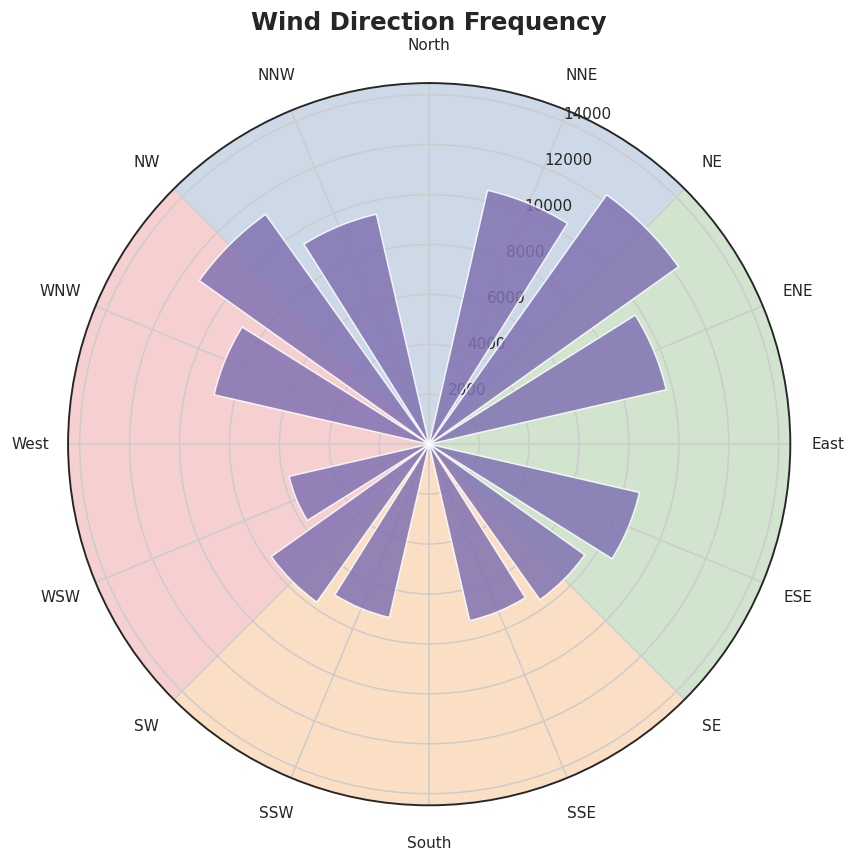

In [107]:
if "wd" in df.columns:
    wd_order = [
        "North", "NNE", "NE", "ENE",
        "East", "ESE", "SE", "SSE",
        "South", "SSW", "SW", "WSW",
        "West", "WNW", "NW", "NNW"
    ]

    wd_counts = (
        df["wd"]
        .value_counts()
        .reindex(wd_order)
        .fillna(0)
    )

    angles = np.linspace(0, 2 * np.pi, len(wd_order), endpoint=False)
    width = 2 * np.pi / len(wd_order)

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": "polar"}
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    max_count = wd_counts.max() * 1.18

    sector_info = [
        ("North", 315, 45,  "#4E79A7"),
        ("East",   45, 135, "#59A14F"),
        ("South", 135, 225, "#F28E2B"),
        ("West",  225, 315, "#E15759")
    ]

    for label, start_deg, end_deg, color in sector_info:
        if start_deg > end_deg:
            ax.bar(
                np.deg2rad((start_deg + 360 + end_deg) / 2 % 360),
                max_count,
                width=np.deg2rad((360 - start_deg) + end_deg),
                bottom=0,
                color=color,
                alpha=0.28,
                edgecolor=None,
                zorder=0
            )
        else:
            ax.bar(
                np.deg2rad((start_deg + end_deg) / 2),
                max_count,
                width=np.deg2rad(end_deg - start_deg),
                bottom=0,
                color=color,
                alpha=0.28,
                edgecolor=None,
                zorder=0
            )

    ax.bar(
        angles,
        wd_counts.values,
        width=width * 0.85,
        color="#8172B2",
        alpha=0.85,
        edgecolor="white",
        linewidth=1,
        zorder=2
    )

    ax.set_ylim(0, max_count)
    ax.set_xticks(angles)
    ax.set_xticklabels(wd_order)

    ax.tick_params(axis="x", pad=12)
    ax.tick_params(axis="y", pad=6)

    ax.set_title(
        "Wind Direction Frequency",
        fontsize=16,
        weight="bold",
        pad=35
    )

    plt.subplots_adjust(left=0.12, right=0.88, top=0.88, bottom=0.12)

    save_fig("16_wind_direction_frequency_polar_with_regions_spacious.png")
    plt.show()
    plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/17_pm25_decomposition_trend_monthly_seasonal.png


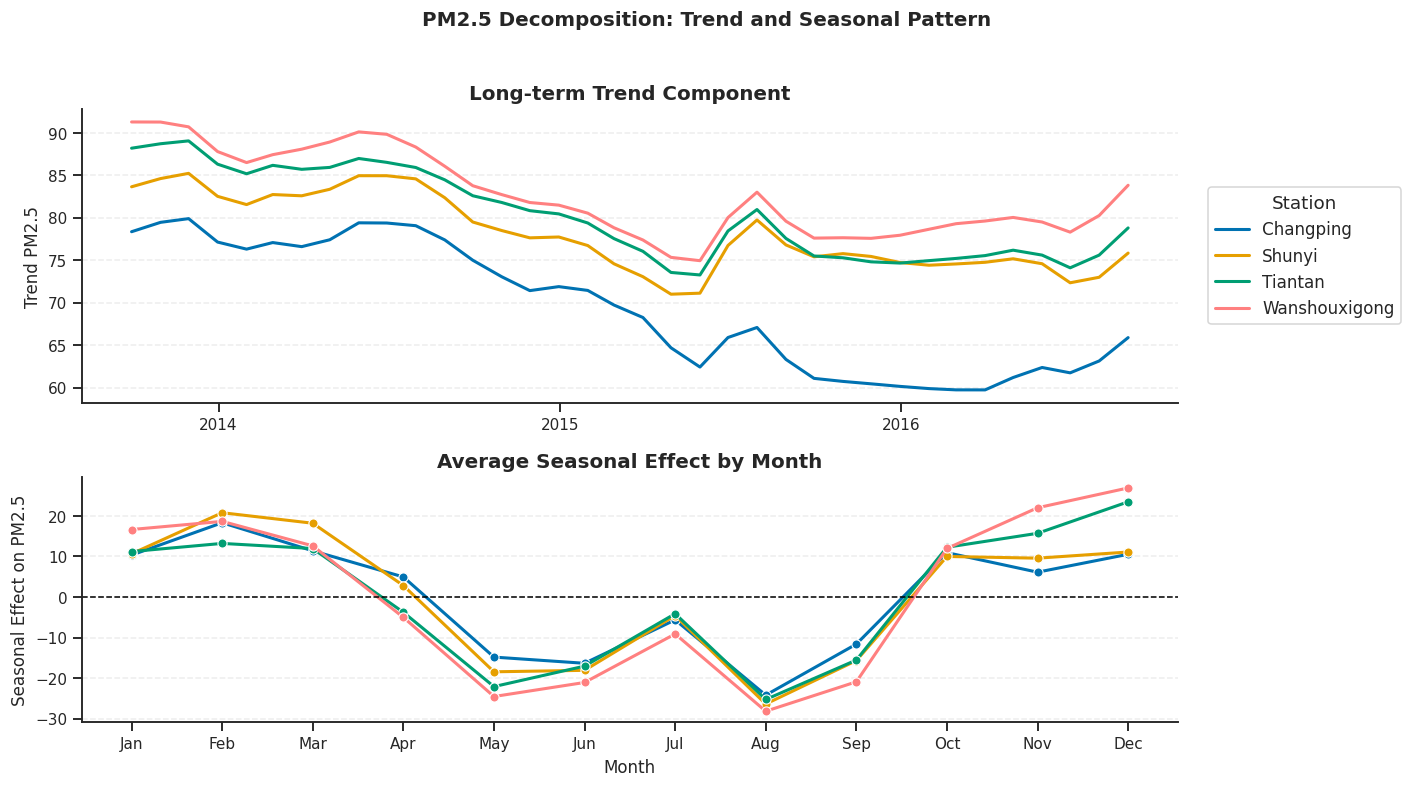

In [108]:
decomp_results = {}

for station in STATION_ORDER:
    station_df = df[df["station"] == station].copy()

    monthly_series = (
        station_df.set_index("datetime")
        .resample("ME")["PM2.5"]
        .mean()
    )

    result = seasonal_decompose(
        monthly_series,
        model="additive",
        period=12
    )

    decomp_results[station] = result

seasonal_monthly_list = []

for station in STATION_ORDER:
    seasonal_series = decomp_results[station].seasonal.dropna()

    temp = pd.DataFrame({
        "datetime": seasonal_series.index,
        "seasonal_effect": seasonal_series.values,
        "station": station
    })

    temp["month"] = temp["datetime"].dt.month
    seasonal_monthly_list.append(temp)

seasonal_monthly = pd.concat(seasonal_monthly_list, ignore_index=True)

seasonal_monthly_avg = (
    seasonal_monthly
    .groupby(["month", "station"])["seasonal_effect"]
    .mean()
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [1.2, 1]})

for station in STATION_ORDER:
    trend_series = decomp_results[station].trend.dropna()

    axes[0].plot(
        trend_series.index,
        trend_series.values,
        label=station,
        color=STATION_PALETTE[station],
        linewidth=2
    )

axes[0].set_title("Long-term Trend Component")
axes[0].set_ylabel("Trend PM2.5")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
apply_common_style(ax=axes[0])


ax2 = axes[1]

sns.lineplot(
    data=seasonal_monthly_avg,
    x="month",
    y="seasonal_effect",
    hue="station",
    hue_order=STATION_ORDER,
    palette=STATION_PALETTE,
    linewidth=2,
    marker="o",
    ax=ax2
)

ax2.axhline(0, color="black", linewidth=1, linestyle="--")

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)

ax2.set_title("Average Seasonal Effect by Month")
ax2.set_xlabel("Month")
ax2.set_ylabel("Seasonal Effect on PM2.5")

apply_common_style(ax=ax2)

axes[0].legend(
    title="Station",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

fig.suptitle(
    "PM2.5 Decomposition: Trend and Seasonal Pattern",
    y=1.02,
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "17_pm25_decomposition_trend_monthly_seasonal.png", bbox_inches="tight")
print("Saved:", FIG_DIR / "17_pm25_decomposition_trend_monthly_seasonal.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/18_eda_mean_pollutant_levels_by_station_heatmap.png


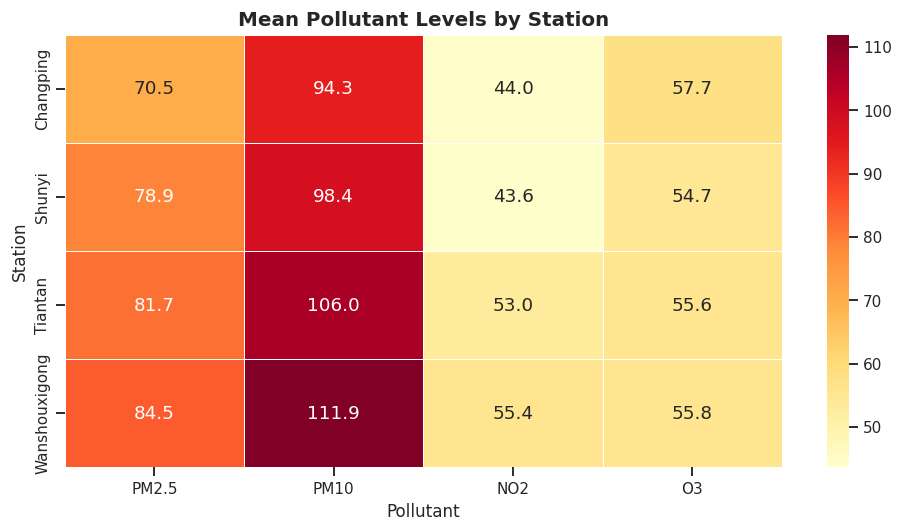

In [109]:
mean_pollution_by_station = (
    df.groupby("station")[pollutant_cols]
      .mean()
      .reindex([s for s in STATION_ORDER if s in df["station"].unique()])
)

selected_cols = [c for c in ["PM2.5", "PM10", "NO2", "O3"] if c in mean_pollution_by_station.columns]

plt.figure(figsize=(9, 5))

ax = sns.heatmap(
    mean_pollution_by_station[selected_cols],
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Mean Pollutant Levels by Station")
plt.xlabel("Pollutant")
plt.ylabel("Station")

plt.tight_layout()
save_fig("18_eda_mean_pollutant_levels_by_station_heatmap.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/19_eda_pollutant_composition_by_station_combined.png


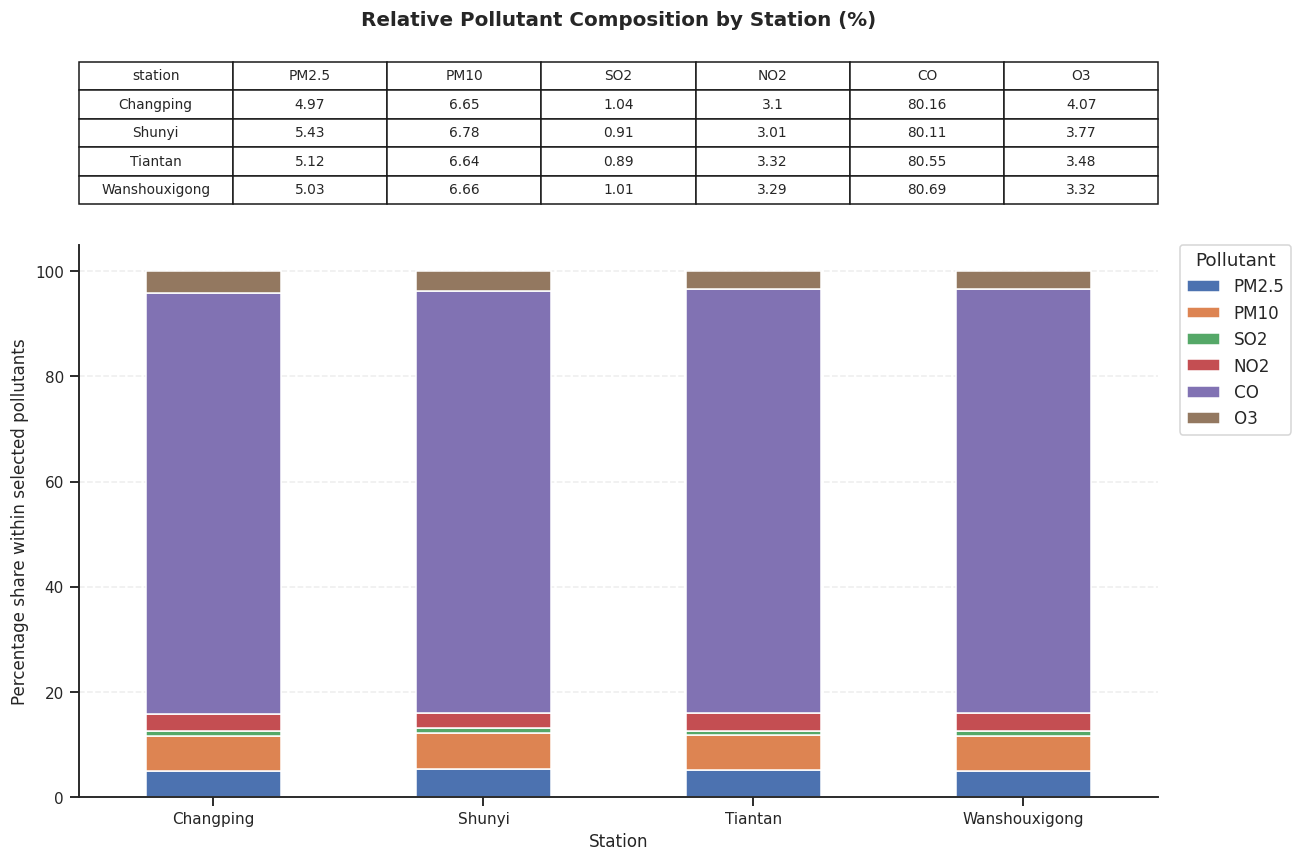

In [110]:
mean_pollution_by_station = (
    df.groupby("station")[pollutant_cols]
    .mean()
    .reindex(STATION_ORDER)
)

pollutant_share = mean_pollution_by_station.copy()
pollutant_share = pollutant_share.div(pollutant_share.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [1, 3]}
)

axes[0].axis("off")

table_data = pollutant_share.round(2).reset_index()

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

axes[0].set_title(
    "Relative Pollutant Composition by Station (%)",
    fontsize=13,
    weight="bold",
    pad=10
)

ax = axes[1]

pollutant_share.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel("Station")
ax.set_ylabel("Percentage share within selected pollutants")
ax.set_xticklabels(pollutant_share.index, rotation=0)

apply_common_style(ax)
place_legend_outside(ax, title="Pollutant")

plt.tight_layout()
save_fig("19_eda_pollutant_composition_by_station_combined.png")
plt.show()
plt.close()

Saved: /content/drive/MyDrive/CMP7005_project/reproducible/figures/20_eda_yearly_average_pollutants_combined.png


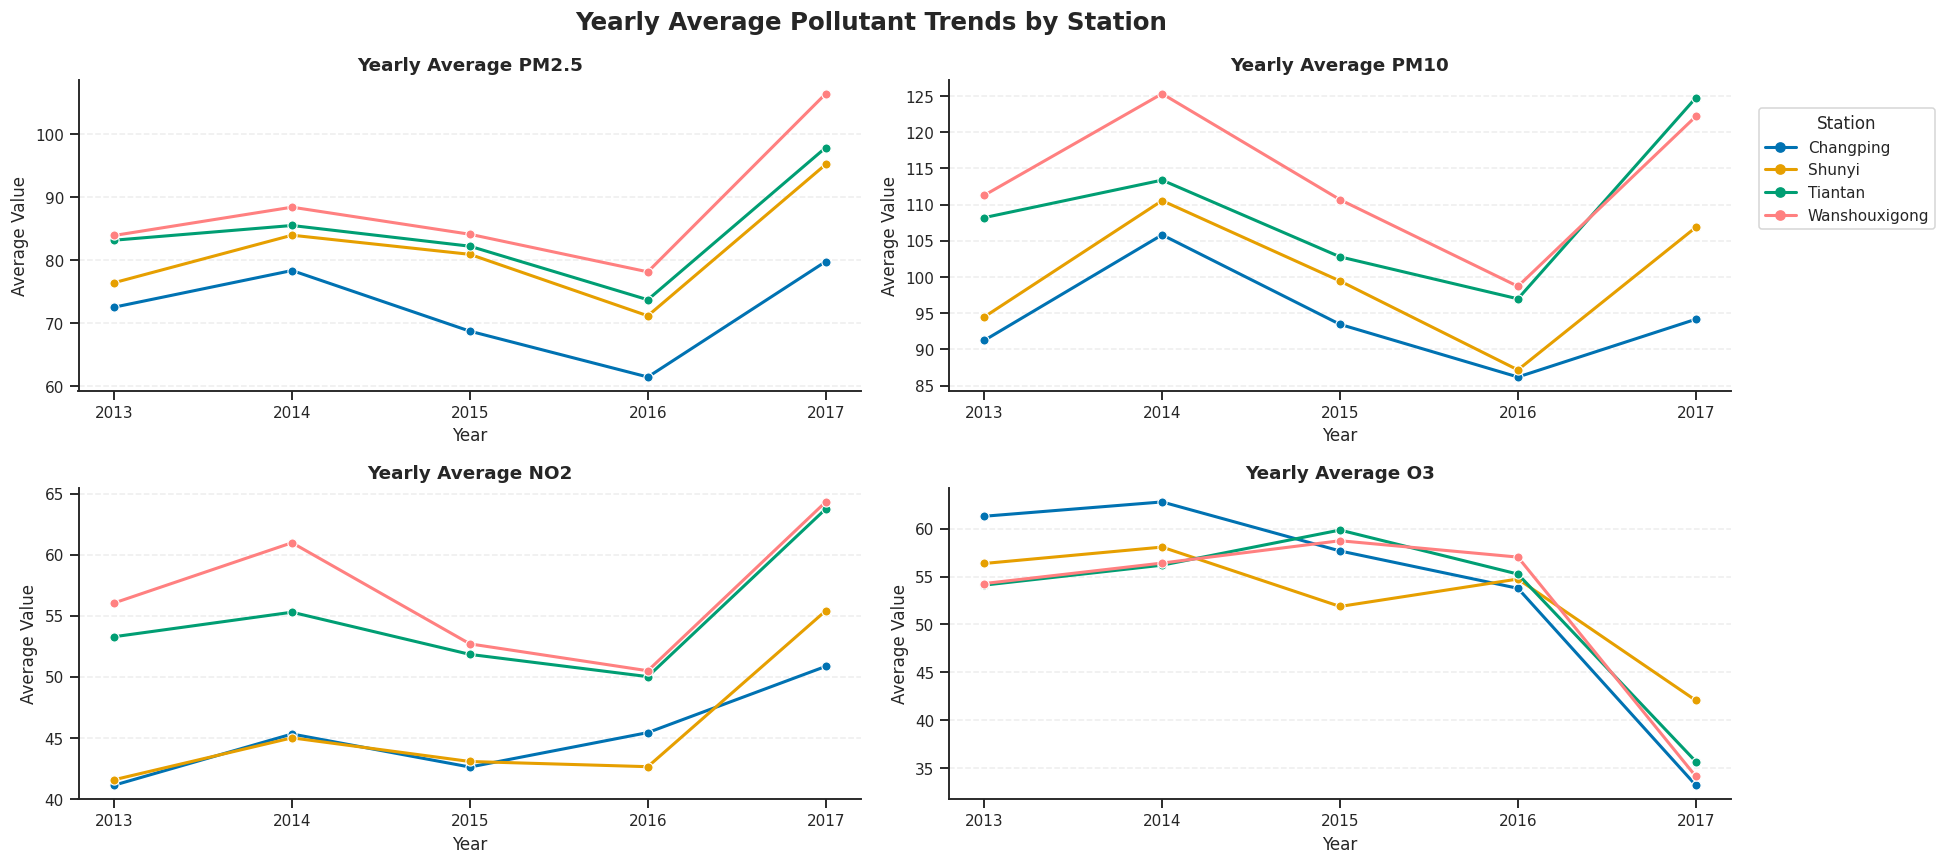

In [111]:
selected_yearly_cols = [
    c for c in ["PM2.5", "PM10", "NO2", "O3"]
    if c in pollutant_cols
]

yearly_pollution = (
    df.groupby(["year_num", "station"])[selected_yearly_cols]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

station_order_present = [
    s for s in STATION_ORDER
    if s in yearly_pollution["station"].unique()
]

for i, col in enumerate(selected_yearly_cols):
    ax = axes[i]

    sns.lineplot(
        data=yearly_pollution,
        x="year_num",
        y=col,
        hue="station",
        hue_order=station_order_present,
        palette=STATION_PALETTE,
        marker="o",
        linewidth=2,
        ax=ax,
        legend=False
    )

    ax.set_title(f"Yearly Average {col}", fontsize=12, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average Value")

    years = sorted(yearly_pollution["year_num"].unique())
    ax.set_xticks(years)
    ax.set_xticklabels([str(int(y)) for y in years])

    apply_common_style(ax)

for j in range(len(selected_yearly_cols), len(axes)):
    fig.delaxes(axes[j])

legend_handles = [
    plt.Line2D(
        [0], [0],
        color=STATION_PALETTE[s],
        marker="o",
        linewidth=2,
        label=s
    )
    for s in station_order_present
]

fig.legend(
    handles=legend_handles,
    labels=station_order_present,
    title="Station",
    loc="center left",
    bbox_to_anchor=(1.00, 0.80),
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle(
    "Yearly Average Pollutant Trends by Station",
    fontsize=16,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 0.86, 0.95])

save_fig("20_eda_yearly_average_pollutants_combined.png")
plt.show()
plt.close()